# Simulating stuff with synthpop and ocelot!

## Imports

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy import units as u
from astroquery.gaia import Gaia
# import gaianir_open_clusters  # noqa: F401
from gaianir_open_clusters.cluster_model import GaiaNIRObservationModel
from gaianir_open_clusters.population import simulate_region
from gaianir_open_clusters.gaia_nir_config import GAIANIR_ANGULAR_RESOLUTION
from gaianir_open_clusters.crowding import apply_cluster_crowding
from ocelot.simulate import (
    SimulatedCluster,
    SimulatedClusterParameters,
    SimulatedClusterModels,
)
from ocelot.model.observation import (
    GaiaDR3ObservationModel,
    GenericSubsampleSelectionFunction,
)
from scipy.stats import poisson, ecdf
from scipy.interpolate import interp1d
from sklearn.neighbors import NearestNeighbors


## Region sim!

In [2]:
l = 10
b = 0

In [3]:
region, crowding_metadata = simulate_region(l, b, 1/60**2, minimum_stars=10000)

Initializing populations for first time...
Simulating region... (attempt 1, area 1.000 arcmin^2)
  now adding photometry for 55934 stars...
Success! Calculating astrometry for 34187 remaining stars.
Applying crowding.
Standardizing columns.


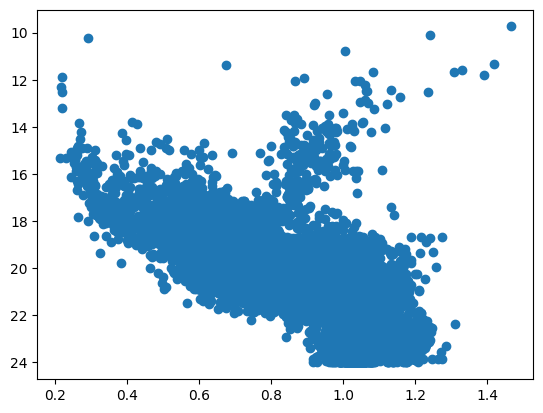

In [4]:
plt.scatter(region['gaianir_j'] - region['gaianir_k'], region['gaianir_n'])
plt.gca().invert_yaxis()

## Cluster sim!

In [5]:
position = SkyCoord(
    l=l * u.deg,
    b=b * u.deg,
    distance=10000 * u.pc,
    pm_l_cosb=10 * u.mas / u.yr,
    pm_b=0 * u.mas / u.yr,
    radial_velocity=0 * u.km / u.s,
    frame="galactic",
)

parameters = SimulatedClusterParameters(
    position=position,
    mass=1000,
    log_age=9,
    metallicity=0.0,
    extinction=5.0,
    r_core=2,
    r_tidal=10,
    virial_ratio=0.5
)

In [6]:
Gaia.ROW_LIMIT = 10000
query = Gaia.cone_search(parameters.position, radius=0.5 * u.deg)
gaia_data = query.get_results().to_pandas().rename(columns={"SOURCE_ID": "source_id"})

In [7]:
models = SimulatedClusterModels(
    observations=[
        GaiaNIRObservationModel(
            mission_class="GaiaNIR-L", years=10, maximum_magnitude=23
        ),
        GaiaNIRObservationModel(
            mission_class="GaiaNIR-M", years=10, maximum_magnitude=23
        ),
        # GaiaNIRObservationModel(
        #     mission_class="Gaia",
        #     years=10,
        #     maximum_magnitude=20,
        #     combined_astrometry=False,
        # ),
        # GaiaNIRObservationModel(
        #     mission_class="Gaia",
        #     years=5,
        #     maximum_magnitude=20,
        #     combined_astrometry=False,
        # ),
        GaiaDR3ObservationModel(
            representative_stars=gaia_data, overestimate_bp_rp_fluxes=False
        ),
    ]
)

In [8]:
cluster = SimulatedCluster(random_seed=42, parameters=parameters, models=models)
cluster.make()

/home/emily/code/gaianir-open-clusters/.venv/lib/python3.13/site-packages/ocelot/model/observation/gaia/gaia_dr3.py:226: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  magnitude = -2.5 * np.log10(flux, where=good_fluxes) + self.ZEROPOINTS[band]


In [9]:
cluster.observations.keys()

dict_keys(['gaianir-l-10-(combined)', 'gaianir-m-10-(combined)', 'gaia_dr3'])

## Various diagnostic plots

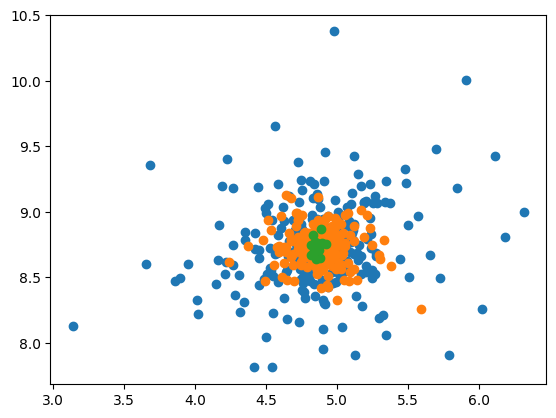

In [10]:
obs_m = cluster.observations['gaianir-m-10-(combined)'].query("gaianir_n < 22")
obs_l = cluster.observations['gaianir-l-10-(combined)'].query("gaianir_n < 22")
# obs_g = cluster.observations['gaia-10'].query("g_effective_gaia < 20")
obs_dr3 = cluster.observations['gaia_dr3'].query("gaia_dr3_g < 20")


plt.scatter(obs_m['pmra'], obs_m['pmdec'])
plt.scatter(obs_l['pmra'], obs_l['pmdec'])
# plt.scatter(obs_g['pmra'], obs_g['pmdec'])
plt.scatter(obs_dr3['pmra'], obs_dr3['pmdec'])

[None]

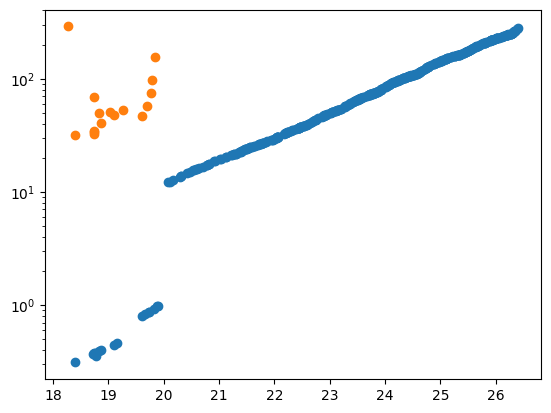

In [11]:
plt.scatter(obs_l['g_effective_gaia'], obs_l['pmra_error']*1000)
plt.scatter(obs_dr3['gaia_dr3_g'], obs_dr3['pmra_error']*1000)
plt.gca().set(yscale="log")

(array([11.,  2.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  1.]),
 array([0.0319135 , 0.05760601, 0.08329852, 0.10899103, 0.13468355,
        0.16037604, 0.18606856, 0.21176109, 0.23745358, 0.2631461 ,
        0.2888386 ]),
 <BarContainer object of 10 artists>)

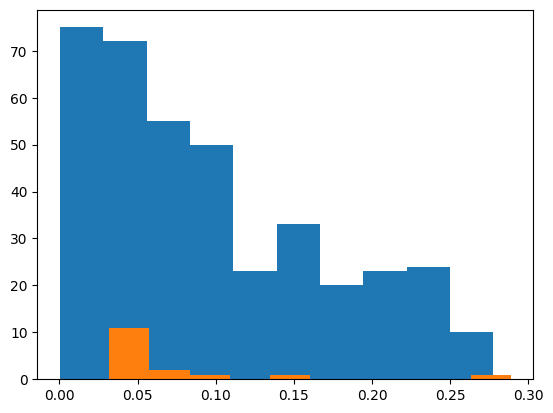

In [12]:
plt.hist(obs_l['pmra_error'])
plt.hist(obs_dr3['pmra_error'])
# plt.gca().set(yscale="log")

[Text(0.5, 0, 'G'), Text(0, 0.5, 'pmra error (uas/yr)')]

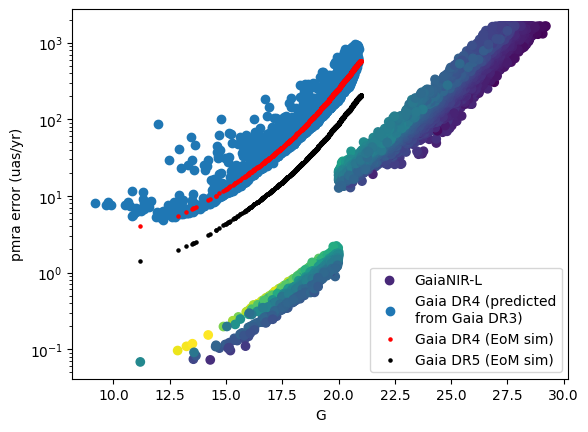

In [13]:
plt.scatter(
    region["gaia_dr3_g"],
    region["pmra_error_gaianir-l_combined"] * 1000,
    c=region["logTeff"],
    label="GaiaNIR-L",
)
plt.gca().set(yscale="log")

plt.scatter(
    gaia_data["phot_g_mean_mag"], gaia_data["pmra_error"] * 1000 / (2 * np.sqrt(2)), label="Gaia DR4 (predicted\nfrom Gaia DR3)"
)
plt.scatter(region["gaia_dr3_g"], region["pmra_error_gaia_dr4"] * 1000, c="r", s=5, label="Gaia DR4 (EoM sim)")
plt.scatter(region["gaia_dr3_g"], region["pmra_error_gaia_dr5"] * 1000, c="k", s=5, label="Gaia DR5 (EoM sim)")
plt.legend()
plt.gca().set(xlabel="G", ylabel="pmra error (uas/yr)")

[Text(0.5, 0, 'N'), Text(0, 0.5, 'pmra error (uas/yr)')]

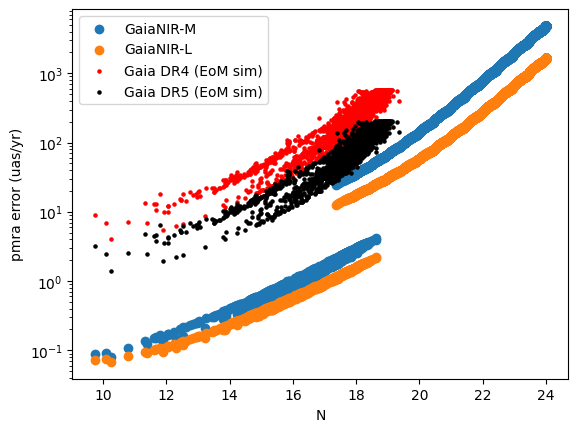

In [14]:
plt.scatter(
    region["gaianir_n"],
    region["pmra_error_gaianir-m_combined"] * 1000,
    # c=region["logTeff"],
    label="GaiaNIR-M",
)
plt.scatter(
    region["gaianir_n"],
    region["pmra_error_gaianir-l_combined"] * 1000,
    # c=region["logTeff"],
    label="GaiaNIR-L",
)
plt.gca().set(yscale="log")

# plt.scatter(
#     gaia_data["phot_g_mean_mag"], gaia_data["pmra_error"] * 1000 / (2 * np.sqrt(2)), label="Gaia DR4 (predicted\nfrom Gaia DR3)"
# )
plt.scatter(region["gaianir_n"], region["pmra_error_gaia_dr4"] * 1000, c="r", s=5, label="Gaia DR4 (EoM sim)")
plt.scatter(region["gaianir_n"], region["pmra_error_gaia_dr5"] * 1000, c="k", s=5, label="Gaia DR5 (EoM sim)")
plt.legend()
plt.gca().set(xlabel="N", ylabel="pmra error (uas/yr)")

## Dealing with crowding

Realization: it's just gonna be Poisson-distributed... hmm...

[(-37.07533715745903, 37.14891632644388),
 (-37.22274537330295, 37.09769536355433)]

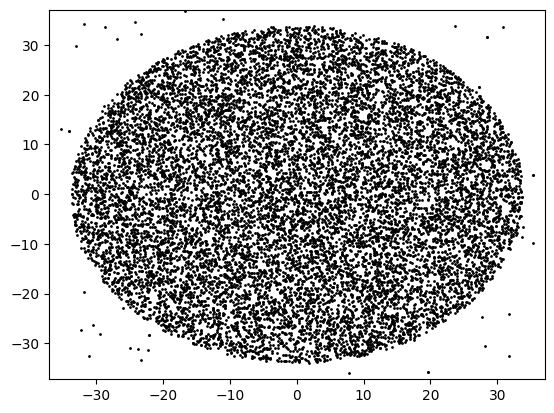

In [15]:
region_good = region.query("gaianir_n < 22").reset_index(drop=True)
obs_good = (
    cluster.observations["gaianir-l-10-(combined)"]
    .query("gaianir_n < 22")
    .sort_values("gaianir_n", ascending=True)
    .reset_index(drop=True)
)

plt.scatter(60**2 * (region_good["l"] - l), 60**2 * (region_good["b"] - b), s=1, c="k")
xlim, ylim = plt.gca().get_xlim(), plt.gca().get_ylim()
plt.scatter(60**2 * (obs_good["l"] - l), 60**2 * (obs_good["b"] - b), s=1, c="k")
plt.gca().set(xlim=xlim, ylim=ylim)
# plt.sca

[(-13.18630465834265, 15.300379003718312),
 (-31.61490324675833, 12.77949498320327)]

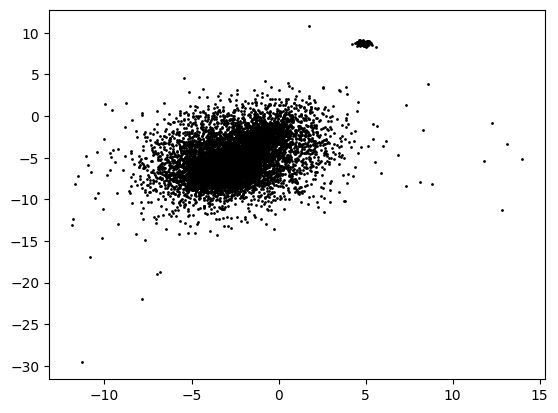

In [16]:
plt.scatter(
    region_good["pmra_gaianir-l_combined"],
    region_good["pmdec_gaianir-l_combined"],
    s=1,
    c="k",
)
xlim, ylim = plt.gca().get_xlim(), plt.gca().get_ylim()
plt.scatter(obs_good["pmra"], obs_good["pmdec"], s=1, c="k")
plt.gca().set(xlim=xlim, ylim=ylim)

HOW ABOUT: I use a fixed background event density, and then also have self-crowding for the cluster? This deals with within-cluster stochasticity AND also removes points nicely. Yay!

In [23]:
crowding_metadata

{'area': 0.0002777777777777778,
 'magnitude_ppfunc': <scipy.interpolate._interpolate.interp1d at 0x741af0133480>,
 'density_param_gaia': np.float64(0.40697938913250575),
 'density_param_gaianir-m': np.float64(1.5705213518893246),
 'density_param_gaianir-l': np.float64(0.3705148332212364)}

In [26]:
observation = cluster.observations["gaianir-l-10-(combined)"]

observation_good = apply_cluster_crowding(
    observation,
    crowding_metadata["density_param_gaianir-l"],
    crowding_metadata["magnitude_ppfunc"],
    "GaiaNIR-L",
)

len(observation_good), len(observation)

(446, 595)

In [27]:
region.keys()

Index(['pop', 'mass_initial', 'age', 'Fe/H_initial', 'mass', 'distance', 'l',
       'b', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius', 'phase',
       'gaia_dr3_g', 'gaia_dr3_bp_true', 'gaia_dr3_rp_true', '2mass_j',
       '2mass_h', '2mass_k', 'label', 'luminosity', 'temperature', 'log_g',
       'radius', 'gaianir_n', 'gaianir_r', 'gaianir_j', 'gaianir_h',
       'gaianir_k', 'extinction_green', 'extinction_zucker', 'extinction',
       'ra', 'dec', 'pmra_true', 'pmdec_true', 'parallax_true',
       'ra_error_gaianir-l', 'dec_error_gaianir-l', 'pmra_error_gaianir-l',
       'pmdec_error_gaianir-l', 'parallax_error_gaianir-l',
       'ra_error_gaianir-m', 'dec_error_gaianir-m', 'pmra_error_gaianir-m',
       'pmdec_error_gaianir-m', 'parallax_error_gaianir-m',
       'ra_error_gaia_dr4', 'dec_error_gaia_dr4', 'pmra_error_gaia_dr4',
       'pmdec_error_gaia_dr4', 'parallax_error_gaia_dr4', 'ra_error_gaia_dr5',
       'dec_error_gaia_dr5', 'pmra_error_gaia_dr5', 'pmdec_error

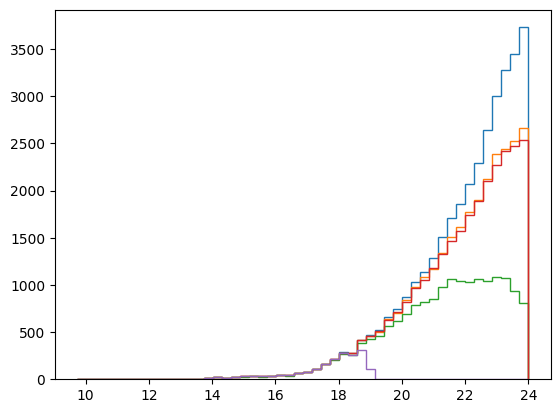

In [35]:
values, bins, _ = plt.hist(region['gaianir_n'], bins=50, histtype="step")
_ = plt.hist(region.query("`uncrowded_gaianir-l`")['gaianir_n'], bins=bins, histtype="step")
_ = plt.hist(region.query("`uncrowded_gaianir-m`")['gaianir_n'], bins=bins, histtype="step")
_ = plt.hist(region.query("uncrowded_gaia")['gaianir_n'], bins=bins, histtype="step")
_ = plt.hist(region.query("uncrowded_gaia and gaia_dr3_g<21")['gaianir_n'], bins=bins, histtype="step")

In [ ]:
region_radiused = region.loc[_radius_crowding(region.sort_values("N", ascending=True), GAIANIR_ANGULAR_RESOLUTION['GaiaNIR-L'])]
len(region_radiused), len(region)

(28476, 33911)

In [ ]:
dat = np.radians(region[['l', 'b']].to_numpy())

neigh = NearestNeighbors(metric="haversine").fit(dat)
distances, indices = neigh.kneighbors(dat, n_neighbors=2)

(array([6.1230e+03, 1.2125e+04, 9.6090e+03, 4.4630e+03, 1.2760e+03,
        2.7200e+02, 3.7000e+01, 5.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([6.91557167e-04, 8.04298432e-02, 1.60168129e-01, 2.39906415e-01,
        3.19644701e-01, 3.99382987e-01, 4.79121273e-01, 5.58859559e-01,
        6.38597845e-01, 7.18336131e-01, 7.98074417e-01]),
 <BarContainer object of 10 artists>)

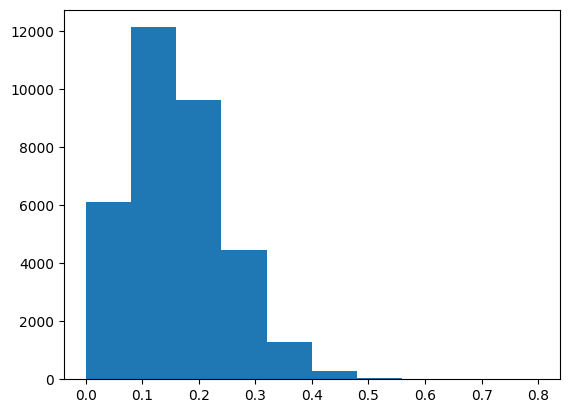

In [ ]:
plt.hist(np.degrees(distances[:, 1])*60**2)

## Aside: are the areas correct?

In [ ]:
area

0.0002777777777777778

In [ ]:
radius = np.sqrt((region['l'] - l)**2 + (region['b'] - b)**2)
np.pi * radius.max()**2

np.float64(0.0002777660078567226)

In [ ]:
area * 60**2

1.0

yes, I just fucked up the squaring there!

In [ ]:
region.columns

Index(['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist',
       'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR',
       'A_None', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius',
       'phase', 'Gaia_G_EDR3', 'Gaia_BP_EDR3', 'Gaia_RP_EDR3', '2MASS_J',
       '2MASS_H', '2MASS_Ks', 'label', 'luminosity', 'temperature', 'log_g',
       'radius', 'N', 'N_R', 'N_J', 'N_H', 'N_K', 'extinction_green',
       'extinction_zucker', 'extinction', 'ra', 'dec', 'pmra_true',
       'pmdec_true', 'parallax_true', 'ra_error_gaianir-l',
       'dec_error_gaianir-l', 'pmra_error_gaianir-l', 'pmdec_error_gaianir-l',
       'parallax_error_gaianir-l', 'ra_error_gaianir-m', 'dec_error_gaianir-m',
       'pmra_error_gaianir-m', 'pmdec_error_gaianir-m',
       'parallax_error_gaianir-m', 'ra_error_gaia_dr4', 'dec_error_gaia_dr4',
       'pmra_error_gaia_dr4', 'pmdec_error_gaia_dr4',
       'parallax_error_gaia_dr4', 'ra_error_gaia_dr5', 'dec_error_gaia